# agentv23_shared_context_store

This version introduces durable shared context using SQLite.

Graph:

```text
START → load_context → planner
                       ├── metrics_agent
                       └── runbook_agent
                              ↓
                         write_context
                              ↓
                         final_answer → END
```


## 1. Install dependencies

```bash
pip install -U langgraph langchain langchain-openai langsmith python-dotenv ipython jupyter
```


In [1]:
# Optional: uncomment in a fresh environment.
# %pip install -U langgraph langchain langchain-openai langsmith python-dotenv ipython jupyter


## 2. Load environment variables


In [2]:
from pathlib import Path
import os
from dotenv import load_dotenv

cwd = Path.cwd()
load_dotenv(cwd / ".env")
load_dotenv(cwd.parent / ".env")

print("OpenAI API key present:", bool(os.getenv("OPENAI_API_KEY")))
print("LangSmith tracing:", os.getenv("LANGSMITH_TRACING"))
print("LangSmith project:", os.getenv("LANGSMITH_PROJECT"))


OpenAI API key present: True
LangSmith tracing: true
LangSmith project: langgraph-playground


## 3. Create SQLite shared context store


In [3]:
import json
import sqlite3
import time
from pathlib import Path
from typing import Any

DB_PATH = Path("shared_context.db")

class SharedContextStore:
    def __init__(self, db_path: str | Path = DB_PATH):
        self.db_path = Path(db_path)
        self.initialize()

    def connect(self) -> sqlite3.Connection:
        conn = sqlite3.connect(self.db_path)
        conn.row_factory = sqlite3.Row
        return conn

    def initialize(self) -> None:
        with self.connect() as conn:
            conn.execute("""
                CREATE TABLE IF NOT EXISTS context_kv (
                    context_id TEXT NOT NULL,
                    key TEXT NOT NULL,
                    value_json TEXT NOT NULL,
                    updated_at REAL NOT NULL,
                    PRIMARY KEY (context_id, key)
                )
            """)
            conn.execute("""
                CREATE TABLE IF NOT EXISTS context_events (
                    id INTEGER PRIMARY KEY AUTOINCREMENT,
                    context_id TEXT NOT NULL,
                    event_type TEXT NOT NULL,
                    source TEXT NOT NULL,
                    message TEXT NOT NULL,
                    payload_json TEXT,
                    created_at REAL NOT NULL
                )
            """)
            conn.execute("""
                CREATE TABLE IF NOT EXISTS context_facts (
                    id INTEGER PRIMARY KEY AUTOINCREMENT,
                    context_id TEXT NOT NULL,
                    fact_type TEXT NOT NULL,
                    fact_key TEXT NOT NULL,
                    fact_value TEXT NOT NULL,
                    confidence REAL NOT NULL,
                    source TEXT NOT NULL,
                    created_at REAL NOT NULL
                )
            """)

    def set_value(self, context_id: str, key: str, value: Any) -> None:
        with self.connect() as conn:
            conn.execute("""
                INSERT INTO context_kv (context_id, key, value_json, updated_at)
                VALUES (?, ?, ?, ?)
                ON CONFLICT(context_id, key)
                DO UPDATE SET value_json=excluded.value_json, updated_at=excluded.updated_at
            """, (context_id, key, json.dumps(value), time.time()))

    def get_all_values(self, context_id: str) -> dict[str, Any]:
        with self.connect() as conn:
            rows = conn.execute(
                "SELECT key, value_json FROM context_kv WHERE context_id = ? ORDER BY key",
                (context_id,),
            ).fetchall()
        return {row["key"]: json.loads(row["value_json"]) for row in rows}

    def add_event(self, context_id: str, event_type: str, source: str, message: str, payload: dict[str, Any] | None = None) -> None:
        with self.connect() as conn:
            conn.execute("""
                INSERT INTO context_events
                (context_id, event_type, source, message, payload_json, created_at)
                VALUES (?, ?, ?, ?, ?, ?)
            """, (context_id, event_type, source, message, json.dumps(payload or {}), time.time()))

    def list_events(self, context_id: str, limit: int = 20) -> list[dict[str, Any]]:
        with self.connect() as conn:
            rows = conn.execute("""
                SELECT event_type, source, message, payload_json, created_at
                FROM context_events
                WHERE context_id = ?
                ORDER BY id DESC
                LIMIT ?
            """, (context_id, limit)).fetchall()

        return [
            {
                "event_type": row["event_type"],
                "source": row["source"],
                "message": row["message"],
                "payload": json.loads(row["payload_json"] or "{}"),
                "created_at": row["created_at"],
            }
            for row in rows
        ]

    def add_fact(self, context_id: str, fact_type: str, fact_key: str, fact_value: str, confidence: float, source: str) -> None:
        with self.connect() as conn:
            conn.execute("""
                INSERT INTO context_facts
                (context_id, fact_type, fact_key, fact_value, confidence, source, created_at)
                VALUES (?, ?, ?, ?, ?, ?, ?)
            """, (context_id, fact_type, fact_key, fact_value, confidence, source, time.time()))

    def list_facts(self, context_id: str, limit: int = 50) -> list[dict[str, Any]]:
        with self.connect() as conn:
            rows = conn.execute("""
                SELECT fact_type, fact_key, fact_value, confidence, source, created_at
                FROM context_facts
                WHERE context_id = ?
                ORDER BY id DESC
                LIMIT ?
            """, (context_id, limit)).fetchall()
        return [dict(row) for row in rows]

    def reset_context(self, context_id: str) -> None:
        with self.connect() as conn:
            conn.execute("DELETE FROM context_kv WHERE context_id = ?", (context_id,))
            conn.execute("DELETE FROM context_events WHERE context_id = ?", (context_id,))
            conn.execute("DELETE FROM context_facts WHERE context_id = ?", (context_id,))


## 4. Define LangGraph state


In [4]:
import operator
from typing import Annotated, NotRequired, TypedDict

DEFAULT_CONTEXT_ID = "epp_incident_context"

class AgentState(TypedDict):
    input: str
    context_id: str
    loaded_context: NotRequired[dict]
    recent_events: NotRequired[list[dict]]
    known_facts: NotRequired[list[dict]]
    plan: NotRequired[str]
    agent_outputs: Annotated[list[str], operator.add]
    final_answer: NotRequired[str]


## 5. Define graph nodes


In [5]:
def load_context_node(state: AgentState) -> AgentState:
    store = SharedContextStore()
    context_id = state["context_id"]

    return {
        "loaded_context": store.get_all_values(context_id),
        "recent_events": store.list_events(context_id, limit=10),
        "known_facts": store.list_facts(context_id, limit=20),
        "agent_outputs": [],
    }

def planner_node(state: AgentState) -> AgentState:
    prior_command = state["loaded_context"].get("preferred_command", "CHECK-DOMAIN")
    threshold = state["loaded_context"].get("risk_threshold_ms", 220)

    return {
        "plan": (
            f"Use shared context. Preferred command is {prior_command}. "
            f"Risk threshold is {threshold} ms. Ask metrics and runbook agents to analyze the incident."
        )
    }

def metrics_agent_node(state: AgentState) -> AgentState:
    store = SharedContextStore()
    context_id = state["context_id"]

    output = (
        "Metrics Agent: CHECK-DOMAIN p95 response_time is around 240 ms after R13. "
        "CONNECTION_TIMEOUT volume is elevated for client_b during peak traffic."
    )

    store.add_event(
        context_id,
        "agent_observation",
        "metrics_agent",
        "Observed elevated CHECK-DOMAIN latency and timeout volume.",
        {"command": "CHECK-DOMAIN", "p95_response_time_ms": 240, "failure_reason": "CONNECTION_TIMEOUT"},
    )
    store.add_fact(context_id, "incident_signal", "primary_command", "CHECK-DOMAIN", 0.95, "metrics_agent")
    store.add_fact(context_id, "incident_signal", "primary_failure_reason", "CONNECTION_TIMEOUT", 0.93, "metrics_agent")

    return {"agent_outputs": [output]}

def runbook_agent_node(state: AgentState) -> AgentState:
    store = SharedContextStore()
    context_id = state["context_id"]

    output = (
        "Runbook Agent: For CHECK-DOMAIN timeout spikes, inspect upstream registry endpoint health, "
        "DNS resolver latency, and connection pool saturation. Rollback if elevated timeout volume "
        "persists for two consecutive hours."
    )

    store.add_event(
        context_id,
        "agent_observation",
        "runbook_agent",
        "Loaded runbook guidance for CHECK-DOMAIN timeout incident.",
        {"recommended_checks": ["registry endpoint health", "DNS resolver latency", "connection pool saturation"]},
    )
    store.add_fact(context_id, "runbook_guidance", "recommended_check", "connection pool saturation", 0.9, "runbook_agent")

    return {"agent_outputs": [output]}

def write_context_node(state: AgentState) -> AgentState:
    store = SharedContextStore()
    context_id = state["context_id"]

    store.set_value(context_id, "preferred_command", "CHECK-DOMAIN")
    store.set_value(context_id, "risk_threshold_ms", 220)
    store.set_value(context_id, "last_user_request", state["input"])
    store.set_value(context_id, "last_plan", state["plan"])

    store.add_event(
        context_id,
        "workflow_summary",
        "langgraph_host",
        "Shared context updated after incident workflow.",
        {"agent_outputs": state["agent_outputs"]},
    )

    return {}


## 6. Define final answer node


In [6]:
from langchain_openai import ChatOpenAI

def final_answer_node(state: AgentState) -> AgentState:
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

    outputs = "\n".join(f"- {item}" for item in state["agent_outputs"])

    prompt = f'''
User request:
{state["input"]}

Loaded shared context:
{state["loaded_context"]}

Recent context events:
{state["recent_events"]}

Known facts:
{state["known_facts"]}

Plan:
{state["plan"]}

Agent outputs:
{outputs}

Write a concise final answer. Mention whether prior shared context influenced the answer.
'''

    response = llm.invoke(prompt)
    return {"final_answer": response.content}


## 7. Build graph


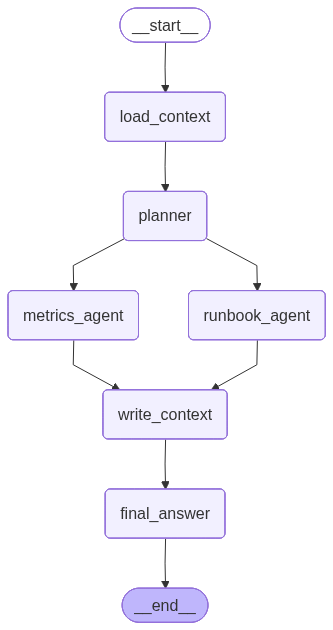

In [7]:
from langgraph.graph import START, END, StateGraph

def build_graph():
    graph_builder = StateGraph(AgentState)

    graph_builder.add_node("load_context", load_context_node)
    graph_builder.add_node("planner", planner_node)
    graph_builder.add_node("metrics_agent", metrics_agent_node)
    graph_builder.add_node("runbook_agent", runbook_agent_node)
    graph_builder.add_node("write_context", write_context_node)
    graph_builder.add_node("final_answer", final_answer_node)

    graph_builder.add_edge(START, "load_context")
    graph_builder.add_edge("load_context", "planner")

    graph_builder.add_edge("planner", "metrics_agent")
    graph_builder.add_edge("planner", "runbook_agent")

    graph_builder.add_edge("metrics_agent", "write_context")
    graph_builder.add_edge("runbook_agent", "write_context")

    graph_builder.add_edge("write_context", "final_answer")
    graph_builder.add_edge("final_answer", END)

    return graph_builder.compile()

graph = build_graph()
graph


## 8. Visualize graph


In [8]:
print(graph.get_graph().draw_mermaid())


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	load_context(load_context)
	planner(planner)
	metrics_agent(metrics_agent)
	runbook_agent(runbook_agent)
	write_context(write_context)
	final_answer(final_answer)
	__end__([<p>__end__</p>]):::last
	__start__ --> load_context;
	load_context --> planner;
	metrics_agent --> write_context;
	planner --> metrics_agent;
	planner --> runbook_agent;
	runbook_agent --> write_context;
	write_context --> final_answer;
	final_answer --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



## 9. Optional: reset context


In [ ]:
# Uncomment to reset this example.
# SharedContextStore().reset_context(DEFAULT_CONTEXT_ID)


## 10. First run


In [13]:
result1 = graph.invoke({
    "input": "Investigate CHECK-DOMAIN timeout spike after release R13.",
    "context_id": DEFAULT_CONTEXT_ID,
})

print(result1["final_answer"])


The investigation into the CHECK-DOMAIN timeout spike after release R13 indicates that the p95 response time has increased to approximately 240 ms, exceeding the risk threshold of 220 ms. The primary failure reason identified is CONNECTION_TIMEOUT, particularly affecting client_b during peak traffic periods. 

The Runbook Agent recommends checking the health of the upstream registry endpoint, DNS resolver latency, and connection pool saturation as potential causes for the timeout spikes. If the elevated timeout volume persists for two consecutive hours, a rollback is advised.

This analysis was influenced by the prior shared context, which emphasized the need to assess EPP timeout risk and provided a structured approach to investigate the incident.


## 11. Inspect stored context


In [14]:
store = SharedContextStore()

print("KV:")
print(store.get_all_values(DEFAULT_CONTEXT_ID))
print()
print("Recent events:")
for event in store.list_events(DEFAULT_CONTEXT_ID, limit=5):
    print(event)
print()
print("Facts:")
for fact in store.list_facts(DEFAULT_CONTEXT_ID, limit=5):
    print(fact)


KV:
{'last_plan': 'Use shared context. Preferred command is CHECK-DOMAIN. Risk threshold is 220 ms. Ask metrics and runbook agents to analyze the incident.', 'last_user_request': 'Investigate CHECK-DOMAIN timeout spike after release R13.', 'preferred_command': 'CHECK-DOMAIN', 'risk_threshold_ms': 220}

Recent events:
{'event_type': 'workflow_summary', 'source': 'langgraph_host', 'message': 'Shared context updated after incident workflow.', 'payload': {'agent_outputs': ['Metrics Agent: CHECK-DOMAIN p95 response_time is around 240 ms after R13. CONNECTION_TIMEOUT volume is elevated for client_b during peak traffic.', 'Runbook Agent: For CHECK-DOMAIN timeout spikes, inspect upstream registry endpoint health, DNS resolver latency, and connection pool saturation. Rollback if elevated timeout volume persists for two consecutive hours.']}, 'created_at': 1782597551.351086}
{'event_type': 'agent_observation', 'source': 'runbook_agent', 'message': 'Loaded runbook guidance for CHECK-DOMAIN timeou

## 12. Second run uses prior context


In [11]:
result2 = graph.invoke({
    "input": "Use previous context and summarize the likely CHECK-DOMAIN issue again.",
    "context_id": DEFAULT_CONTEXT_ID,
})

print(result2["final_answer"])


The CHECK-DOMAIN issue appears to be related to a timeout spike following the R13 release. The Metrics Agent reports that the p95 response time for CHECK-DOMAIN is around 240 ms, exceeding the risk threshold of 220 ms, with an elevated volume of CONNECTION_TIMEOUTs specifically for client_b during peak traffic. The Runbook Agent recommends checking the health of the upstream registry endpoint, DNS resolver latency, and connection pool saturation. If the elevated timeout volume persists for two consecutive hours, a rollback is advised.

This summary is influenced by the prior shared context, which provided details on the incident and the preferred command for investigation.


## 13. Stream graph updates


In [12]:
for chunk in graph.stream(
    {
        "input": "Use shared context to assess EPP timeout risk.",
        "context_id": DEFAULT_CONTEXT_ID,
    },
    stream_mode="updates",
):
    print("\n--- update ---")
    print(chunk.keys())



--- update ---
dict_keys(['load_context'])

--- update ---
dict_keys(['planner'])

--- update ---
dict_keys(['runbook_agent'])

--- update ---
dict_keys(['metrics_agent'])

--- update ---
dict_keys(['write_context'])

--- update ---
dict_keys(['final_answer'])
